In [7]:
from fista.lr import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

In [8]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.6, random_state=1)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test, train_size=0.5, random_state=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [9]:
lr = LogisticRegression(lmbd = 0.3, max_iter = 1000, tol = 1e-4)
lr.fit(X_train, y_train)
pred = lr.predict_proba(X_test) > 0.5
ba = balanced_accuracy_score(y_test, pred)
print(f"Balanced accuracy for test set and lambda = 0.3: {ba}")

Balanced accuracy for test set and lambda = 0.3: 0.9727941176470588


/Users/ola/projects/aml-project-1/src/fista/lr.py:154: RuntimeWarning: For lambda = 0.3, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(


In [10]:
# sets the optimal lambda and corresponding betas 
lr.validate(X_valid, y_valid, measure="bal_acc")
pred = lr.predict_proba(X_test) > 0.5
ba = balanced_accuracy_score(y_test, pred)
print(f"Best lambda based on balanced accuracy on validation set: {lr.lmbd}")
print(f"Balanced accuracy on test set for optimized lambda: {ba}")

Best lambda based on balanced accuracy on validation set: 0.05
Balanced accuracy on test set for optimized lambda: 0.9580882352941176


/Users/ola/projects/aml-project-1/src/fista/lr.py:154: RuntimeWarning: For lambda = 0.005, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:154: RuntimeWarning: For lambda = 0.01, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:154: RuntimeWarning: For lambda = 0.05, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:154: RuntimeWarning: For lambda = 0.1, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:154: RuntimeWarning: For lambda = 0.3, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:154: RuntimeWarning: For lambda = 0.5, max_iter = 1000 and tol = 0.0001 the algorithm did not co

In [11]:
lr.beta

array([-0.00000000e+00,  4.04368591e-01, -7.63002164e-03, -0.00000000e+00,
        1.23773957e+00,  3.27355818e+00,  7.50962076e-02, -8.60678357e+00,
       -1.70214796e-01,  2.86166809e+00, -1.03065627e+01, -1.26222207e+00,
       -7.99663603e-02, -3.68144316e-02,  3.06496000e+00,  3.44339282e+00,
        0.00000000e+00, -5.77844589e+00, -1.15651986e+00,  1.00280562e+01,
       -3.48432575e+00, -3.76791606e+00, -2.26671053e+00, -1.30312620e+00,
       -1.99705282e+00, -2.46382746e+00, -2.49903753e+00,  8.48494749e-01,
       -9.71026253e-01, -7.36065455e+00])

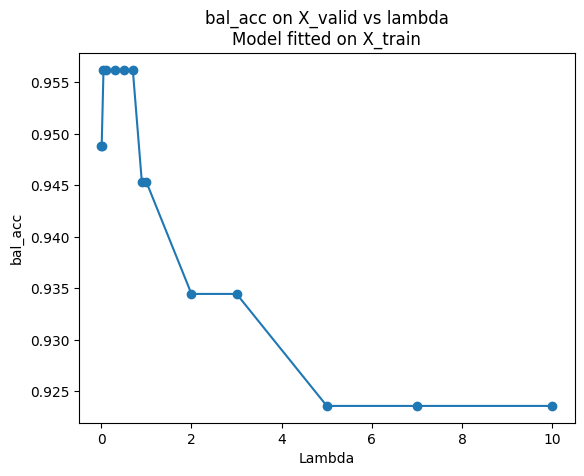

In [12]:
lr.plot("bal_acc")

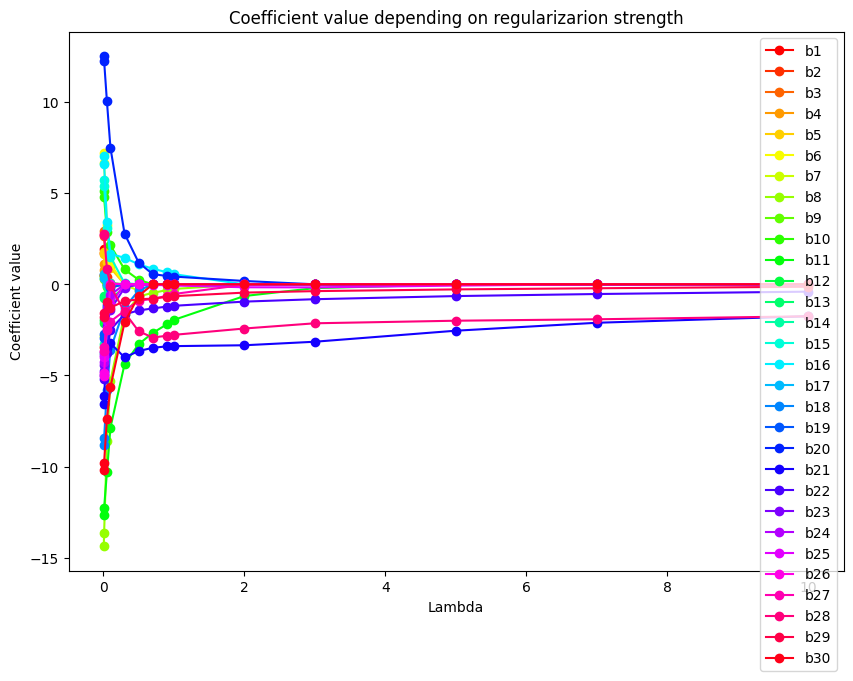

In [13]:
lr.plot_coefficients()